<a href="https://colab.research.google.com/github/d4n4h8/Discovering-Emergent-Visual-Identities/blob/main/AI_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Discovering Emergent Visual Identities in Static Images**


## **STAGE 1: Data Acquisition & Setup**


In this stage, the dataset is loaded and prepared. The system retrieves image paths and their corresponding labels from the dataset directory.

**1. Import Dataset**



In [12]:
import kagglehub

# Download the dataset from KaggleHub
path = kagglehub.dataset_download("stepanyarullin/interior-design-styles")

# Print the dataset root path
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'interior-design-styles' dataset.
Path to dataset files: /kaggle/input/interior-design-styles


In [13]:
import os
# Training dataset path
DATASET_PATH = os.path.join(path, "dataset_train/dataset_train")

# Fixed image size
IMAGE_SIZE = (224, 224)

# Allowed image types
SUPPORTED_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

**2. Import Libraries**

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage.feature import local_binary_pattern
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score
from collections import Counter
from sklearn.manifold import TSNE


## **STAGE 2: Data Exploration**


This stage analyzes the dataset by examining label distribution and visual samples to better understand the data structure and diversity.

**1. Load Dataset**

In [15]:
def load_dataset(dataset_path):
    """
    Load image paths and style labels from dataset folders.
    """
    image_paths = []
    true_labels = []

    for folder_name in os.listdir(dataset_path):
        folder_path = os.path.join(dataset_path, folder_name)

        # Skip non-folder items
        if not os.path.isdir(folder_path):
            continue

        # Collect valid image files and assign their style label
        for file_name in os.listdir(folder_path):
            if file_name.lower().endswith(SUPPORTED_EXTENSIONS):
                full_path = os.path.join(folder_path, file_name)
                image_paths.append(full_path)
                true_labels.append(folder_name)

    return image_paths, true_labels

# Load all dataset image paths and labels
image_paths, true_labels = load_dataset(DATASET_PATH)

print("Dataset path:", DATASET_PATH)
print("Total images found:", len(image_paths))
print("Number of categories:", len(set(true_labels)))
print("Sample categories:", list(set(true_labels))[:10])
print("Sample image paths:", image_paths[:5])

Dataset path: /kaggle/input/interior-design-styles/dataset_train/dataset_train
Total images found: 14876
Number of categories: 19
Sample categories: ['asian', 'mid-century-modern', 'french-country', 'eclectic', 'craftsman', 'farmhouse', 'industrial', 'mediterranean', 'scandinavian', 'modern']
Sample image paths: ['/kaggle/input/interior-design-styles/dataset_train/dataset_train/tropical/tropical_33.jpg', '/kaggle/input/interior-design-styles/dataset_train/dataset_train/tropical/tropical_608.jpg', '/kaggle/input/interior-design-styles/dataset_train/dataset_train/tropical/tropical_662.jpg', '/kaggle/input/interior-design-styles/dataset_train/dataset_train/tropical/tropical_297.jpg', '/kaggle/input/interior-design-styles/dataset_train/dataset_train/tropical/tropical_818.jpg']


**2. Limit Dataset**

In [16]:
# Set random seed
random.seed(42)

# Shuffle image-label pairs
combined = list(zip(image_paths, true_labels))
random.shuffle(combined)

# Select a subset for faster experimentation
sample_size = 5500
combined = combined[:sample_size]

# Unzip shuffled subset back into separate lists
image_paths, true_labels = zip(*combined)
image_paths = list(image_paths)
true_labels = list(true_labels)

print("Using subset of:", len(image_paths))

Using subset of: 5500


**3. Analyze Label Distribution**

In [17]:
def analyze_label_diversity(true_labels):
    """
    Count how many images belong to each style.
    """
    label_counts = Counter(true_labels)

    # print number of images in each class
    print("Label distribution:")
    for label, count in label_counts.items():
        print(f"{label}: {count}")

    return label_counts

# Analyze dataset balance
label_counts = analyze_label_diversity(true_labels)

Label distribution:
coastal: 296
farmhouse: 287
contemporary: 297
asian: 279
mediterranean: 298
eclectic: 304
rustic: 307
modern: 282
craftsman: 287
tropical: 292
transitional: 300
scandinavian: 262
mid-century-modern: 291
traditional: 306
french-country: 292
shabby-chic-style: 281
southwestern: 285
industrial: 291
victorian: 263


**4. Plot Label Distribution**

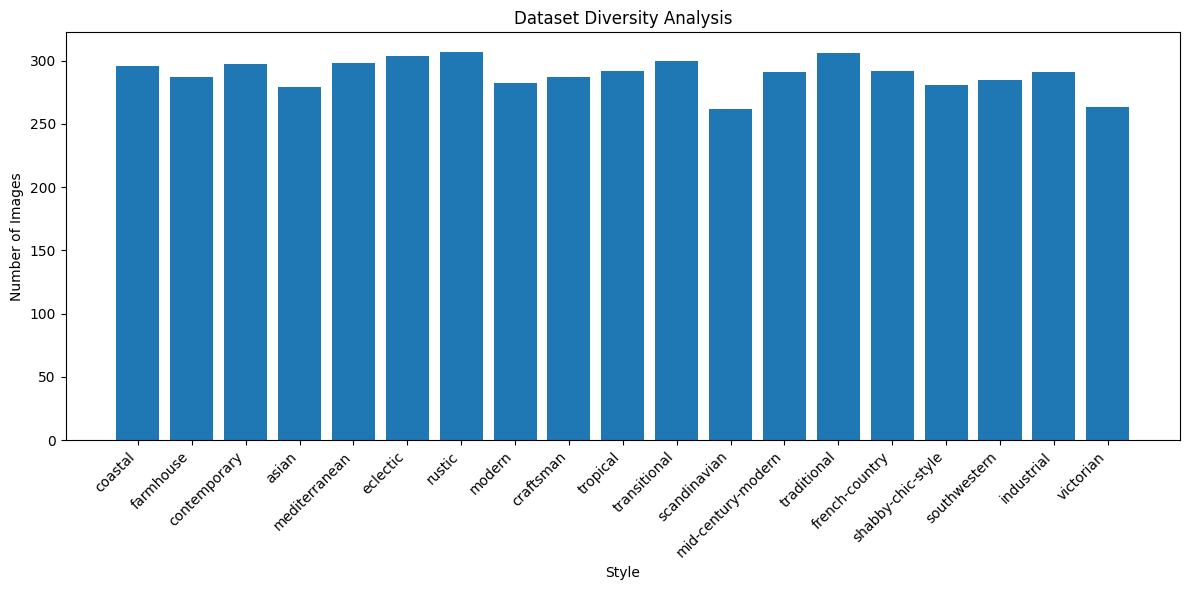

In [18]:
def plot_label_distribution(label_counts):
    """
    Plot the number of images per style.
    """
    labels_list = list(label_counts.keys())
    counts = list(label_counts.values())

    # simple bar chart
    plt.figure(figsize=(12, 6))
    plt.bar(labels_list, counts)
    plt.xticks(rotation=45, ha='right')
    plt.title("Dataset Diversity Analysis")
    plt.xlabel("Style")
    plt.ylabel("Number of Images")
    plt.tight_layout()
    plt.show()

plot_label_distribution(label_counts)

**5. Analyze Image Sizes**

In [19]:
def analyze_image_sizes(image_paths):
    """
    Check original image dimensions across the dataset.
    """
    widths = []
    heights = []

    # collect original image sizes
    for path in image_paths:
        image = cv2.imread(path)
        if image is not None:
            h, w = image.shape[:2]
            widths.append(w)
            heights.append(h)

    # Handle the case where no valid images are found
    if len(widths) == 0:
        print("No valid images were found.")
        return

    print("Original image size analysis")
    print("Min Width:", min(widths))
    print("Max Width:", max(widths))
    print("Min Height:", min(heights))
    print("Max Height:", max(heights))
    print("Average Width:", round(np.mean(widths), 2))
    print("Average Height:", round(np.mean(heights), 2))

# Check whether image sizes are consistent
analyze_image_sizes(image_paths)

Original image size analysis
Min Width: 360
Max Width: 360
Min Height: 360
Max Height: 360
Average Width: 360.0
Average Height: 360.0



## **STAGE 3: Image Preprocessing**


Images are resized and normalized to ensure consistent input format, which improves the quality of feature extraction.

**1. Resize Image**

In [20]:
# Resize for consistent feature extraction
def resize_image(image, size=IMAGE_SIZE):
    return cv2.resize(image, size)

**2. Normalize Image**

In [21]:
# Normalize pixel values to [0,1] to stabilize model input and improve learning consistency
def normalize_image(image):
    return image.astype(np.float32) / 255.0

**3. Preprocess Dataset**

In [22]:
def preprocess_image(path):
    """
    Read image, convert to RGB, resize, and normalize.
    """
    image = cv2.imread(path)
    if image is None:
        return None

    # Convert image from BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize, normalize image
    image = resize_image(image)
    image = normalize_image(image)
    return image


def preprocess_dataset(image_paths):
    """
    Preprocess all images and keep valid file paths only.
    """
    processed_images = []
    valid_paths = []

    # Apply preprocessing to all images
    for path in image_paths:
        processed = preprocess_image(path)
        if processed is not None:
            processed_images.append(processed)
            valid_paths.append(path)

    return np.array(processed_images), valid_paths

# Preprocess the selected subset
processed_images, valid_paths = preprocess_dataset(image_paths)

print("Successfully processed images:", len(processed_images))
print("Processed images shape:", processed_images.shape)

Successfully processed images: 5500
Processed images shape: (5500, 224, 224, 3)


**4. Show Sample Images**

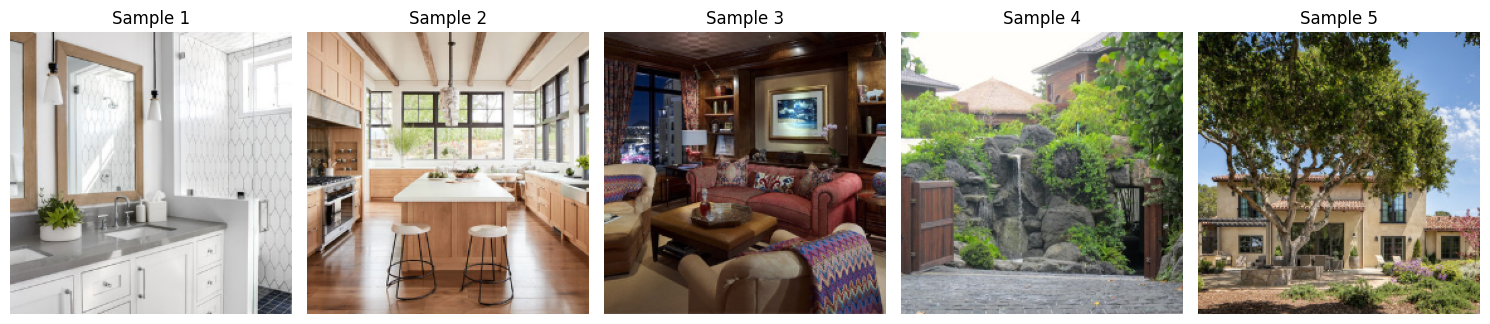

In [23]:
def show_sample_images(processed_images, num_samples=5):
    """
    Display a few sample preprocessed images.
    """

    # Stop if there are no processed images
    if len(processed_images) == 0:
        print("No images to display.")
        return

    # Display a few example preprocessed images
    plt.figure(figsize=(15, 4))
    for i in range(min(num_samples, len(processed_images))):
        plt.subplot(1, min(num_samples, len(processed_images)), i + 1)
        plt.imshow(processed_images[i])
        plt.axis("off")
        plt.title(f"Sample {i+1}")
    plt.tight_layout()
    plt.show()

# Show example preprocessed images
show_sample_images(processed_images, num_samples=5)

**5. Save processed images for reuse**

In [24]:
# Save processed images for reuse
SAVE_PATH = "/content/processed_images.npy"
np.save(SAVE_PATH, processed_images)

print("Processed images saved at:", SAVE_PATH)

Processed images saved at: /content/processed_images.npy



## **STAGE 4: Feature Extraction**

In this stage, each image is converted into a numerical representation using a combination of deep features (ResNet50), color histograms, and texture descriptors.

**Hybrid Feature Extraction**

In [25]:
# Load processed images
processed_images = np.load("/content/processed_images.npy")
print("Loaded processed images:", processed_images.shape)

# 1. Load pre-trained ResNet50 for deep feature extraction
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

Loaded processed images: (5500, 224, 224, 3)
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [26]:
# 2. Deep Features Extraction in batches for better speed and memory efficiency
def extract_deep_features_batch(images, batch_size=32):
    features = []

    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        batch = np.array(batch)

        # Apply ResNet preprocessing
        batch_preprocessed = preprocess_input(batch * 255.0)
        # Extract deep feature vectors
        batch_features = resnet_model.predict(batch_preprocessed, verbose=0)

        features.append(batch_features)

    # Combine all batch outputs into one matrix
    return np.vstack(features)

In [27]:
# 3. Color Histogram Extraction
def extract_color_histogram(img, bins=(8, 8, 8)):
    # Convert normalized image back to uint8 format
    img_uint8 = (img * 255).astype(np.uint8)

    # Compute 3D RGB color histogram
    hist = cv2.calcHist([img_uint8], [0, 1, 2], None, bins, [0,256,0,256,0,256])

    # Normalize histogram values
    hist = cv2.normalize(hist, hist).flatten()
    return hist

# 4. Texture Features (LBP)
def extract_lbp_texture(img, P=8, R=1):
    # Convert normalized image back to uint8 format
    img_uint8 = (img * 255).astype(np.uint8)

    # Convert RGB image to grayscale for texture extraction
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    # Compute Local Binary Pattern
    lbp = local_binary_pattern(gray, P, R, method="uniform")

    # Convert LBP output into a normalized histogram
    hist, _ = np.histogram(lbp.ravel(), bins=int(lbp.max()+1), range=(0, lbp.max()+1))
    hist = hist.astype("float") / (hist.sum() + 1e-6)
    return hist

In [28]:
# 5. Apply to all images
# Extract deep semantic features from all images in batches
deep_features = extract_deep_features_batch(processed_images, batch_size=32)

# Extract handcrafted color features for all images
color_features = np.array([extract_color_histogram(img) for img in processed_images])

# Extract handcrafted texture features for all images
texture_features = np.array([extract_lbp_texture(img) for img in processed_images])

# Concatenate deep, color, and texture features into one hybrid feature vector
hybrid_features = np.concatenate([
    deep_features,
    color_features,
    texture_features
], axis=1)

In [29]:
# Standardize features before PCA and clustering
scaler = StandardScaler()
features_scaled = scaler.fit_transform(hybrid_features)

print("Hybrid features shape:", features_scaled.shape)

Hybrid features shape: (5500, 2570)



## **STAGE 5: Dimensionality Reduction**

PCA is applied to reduce the high-dimensional feature space into a more compact form while preserving important visual information.

In [30]:
# Reduce high-dimensional feature space
pca = PCA(n_components=200)
features_pca = pca.fit_transform(features_scaled)


## **STAGE 6: Baseline Clustering Model**

K-Means is used as the baseline clustering model.

In [31]:
range_k = [3, 4, 5, 6]
best_k = 3
best_score = -1

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(features_pca)

    score = silhouette_score(features_pca, labels)
    print(f"K={k}, Score={score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"Best K: {best_k}")

# Use the best K
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(features_pca)
k = best_k

K=3, Score=0.0674
K=4, Score=0.0724
K=5, Score=0.0067
K=6, Score=0.0065
Best K: 4



## **STAGE 7: Visualization**

Visualizations such as t-SNE plots, and representative images are used to interpret and analyze the clustering results.

Generating 2D Visual Map:


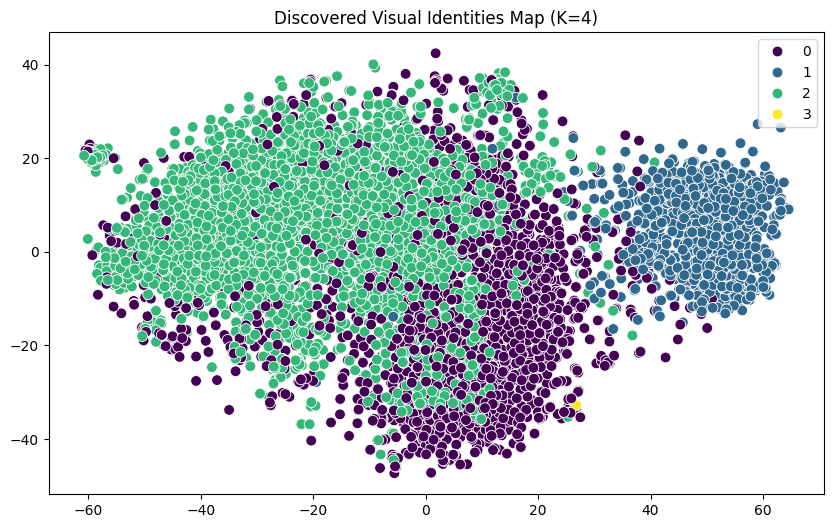

In [32]:
# 1: 2D Cluster Map (t-SNE)
# Show how the machine separated the styles in a 2D space
print("Generating 2D Visual Map:")
tsne = TSNE(n_components=2, random_state=42)
projection = tsne.fit_transform(features_pca)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=projection[:, 0], y=projection[:, 1], hue=kmeans_labels, palette='viridis', s=60)
plt.title(f"Discovered Visual Identities Map (K={k})")
plt.show()

Showing images for each identity:


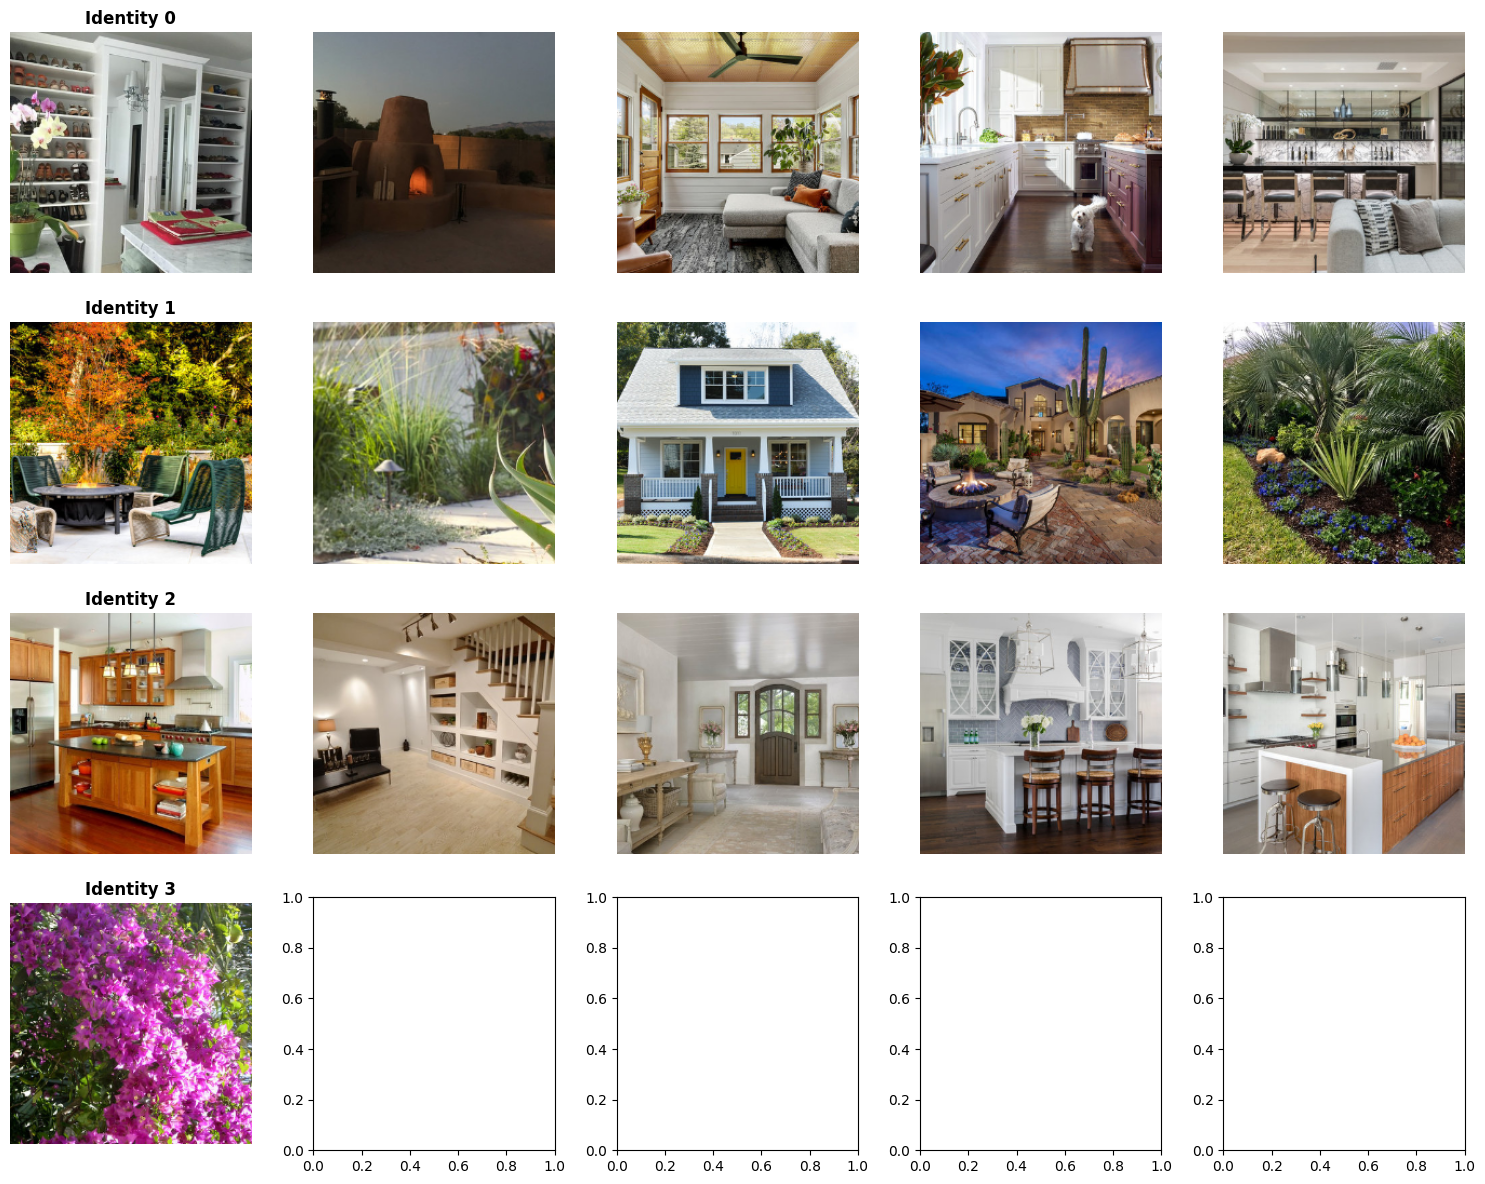

In [33]:
# 2: Representative Images (Visual Identities)
# Show the actual images for each cluster to see the "Identity"
print("Showing images for each identity:")
num_cols = 5
fig, axes = plt.subplots(k, num_cols, figsize=(15, k * 3))

for i in range(k):
    cluster_idx = np.where(kmeans_labels == i)[0]

    if len(cluster_idx) > 0:
        num_samples = min(num_cols, len(cluster_idx))
        selected = np.random.choice(cluster_idx, num_samples, replace=False)

        for j in range(num_samples):
            ax = axes[i, j] if k > 1 else axes[j]
            ax.imshow(processed_images[selected[j]])
            ax.axis('off')
            if j == 0:
                ax.set_title(f"Identity {i}", fontweight='bold')

    else:
        for j in range(num_cols):
            ax = axes[i, j] if k > 1 else axes[j]
            ax.axis('off')
            if j == 0:
                ax.set_title(f"Identity {i} (Empty)", fontweight='bold')
plt.tight_layout()
plt.show()

Analyzing correlation with original labels:


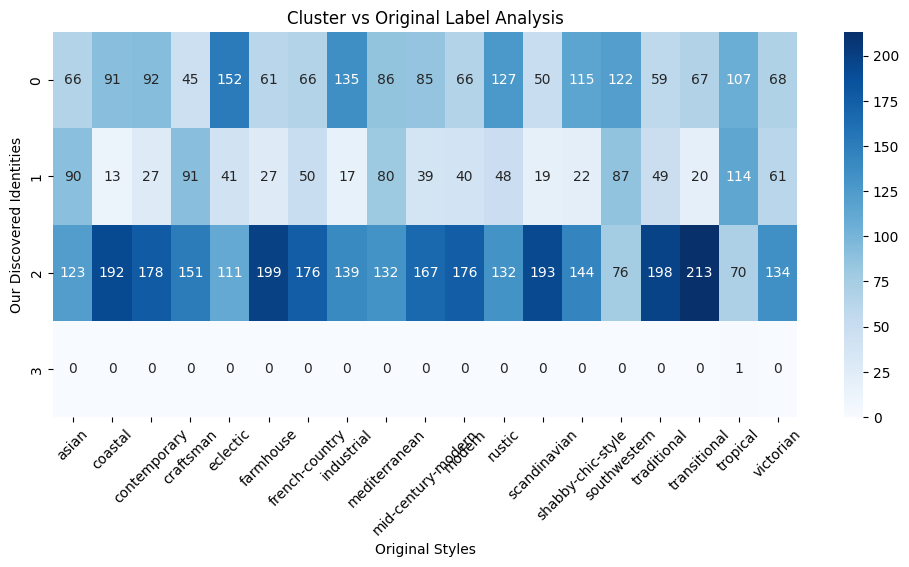

Identity 0 is mostly composed of: eclectic
Identity 1 is mostly composed of: tropical
Identity 2 is mostly composed of: transitional
Identity 3 is mostly composed of: tropical


In [34]:
# 3: Comparison Analysis (Heatmap)
# Compare our clusters with the original style labels
print("Analyzing correlation with original labels:")
# Create a count matrix
unique_true_labels = sorted(list(set(true_labels)))
matrix = np.zeros((k, len(unique_true_labels)))

for i in range(len(kmeans_labels)):
    row = kmeans_labels[i]
    col = unique_true_labels.index(true_labels[i])
    matrix[row, col] += 1

plt.figure(figsize=(12, 5))
sns.heatmap(matrix, annot=True, fmt='g', cmap='Blues', xticklabels=unique_true_labels)
plt.title("Cluster vs Original Label Analysis")
plt.xlabel("Original Styles")
plt.ylabel("Our Discovered Identities")
plt.xticks(rotation=45)
plt.show()

for i in range(k):
    common_style_idx = np.argmax(matrix[i])
    common_style_name = unique_true_labels[common_style_idx]
    print(f"Identity {i} is mostly composed of: {common_style_name}")


## **STAGE 8: Evaluation**

The clustering performance is evaluated using silhouette score and qualitative analysis to assess the quality and meaning of the clusters.

**1. Quantitative Evaluation & Performance Metrics**

In [35]:
# Performance Metrics
print(f"--- Final System Evaluation ---")

# Higher scores (closer to 1) indicate better defined visual identities.
final_score = silhouette_score(features_pca, kmeans_labels)

print(f"Overall Identity Consistency (Silhouette Score): {final_score:.4f}")

--- Final System Evaluation ---
Overall Identity Consistency (Silhouette Score): 0.0724


## **DEMOS**

The system is tested on new or random images to demonstrate how it assigns images to the discovered visual identities.

**1. Inference System using Random Sampling**

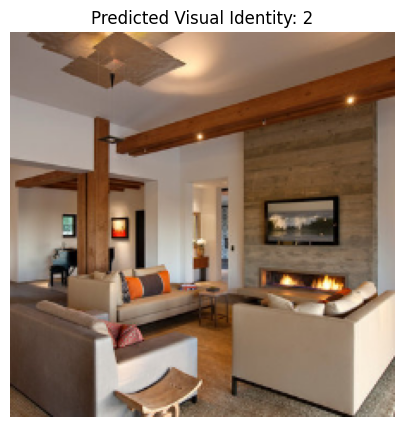

Image file: mediterranean_326.jpg
Predicted cluster: 2


In [36]:
# Select a random image from the dataset
test_img_path = valid_paths[random.randint(0, len(valid_paths)-1)]

# Preprocess the image (resize + normalize)
img = preprocess_image(test_img_path)

# Extract deep features, color features, and texture features
feat_deep = extract_deep_features_batch(np.array([img]), batch_size=1)
feat_color = extract_color_histogram(img).reshape(1, -1)
feat_texture = extract_lbp_texture(img).reshape(1, -1)

# Build hybrid feature vector
feat = np.concatenate([
    feat_deep,
    feat_color * 0.5,
    feat_texture * 0.5
], axis=1)

# Apply the same scaling and PCA used during training
feat_scaled = scaler.transform(feat)
feat_pca = pca.transform(feat_scaled)

# Predict the cluster
pred = kmeans.predict(feat_pca)[0]

# Display the image with its predicted cluster
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"Predicted Visual Identity: {pred}")
plt.axis("off")
plt.show()

# Print additional information
print("Image file:", os.path.basename(test_img_path))
print("Predicted cluster:", pred)

**2. Real-world Inference on External Data**

Please upload an interior design image:


Saving test1.jpg to test1.jpg


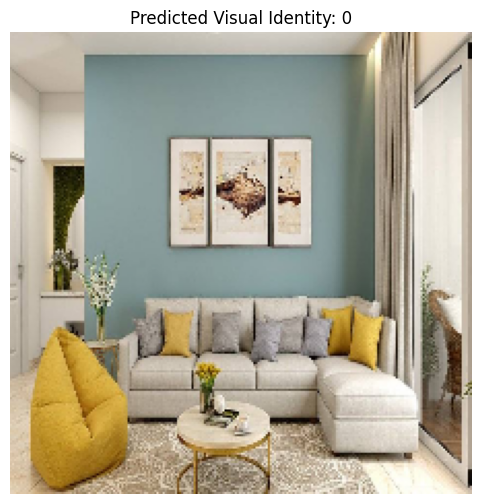

File: test1.jpg
Predicted cluster: 0


In [37]:
from google.colab import files

# Ask user to upload an image
print("Please upload an interior design image:")
uploaded = files.upload()

# Loop through uploaded files
for filename in uploaded.keys():

    external_path = filename

    # Preprocess image
    img = preprocess_image(external_path)

    # Extract deep features, color features, and texture features
    feat_deep = extract_deep_features_batch(np.array([img]), batch_size=1)
    feat_color = extract_color_histogram(img).reshape(1, -1)
    feat_texture = extract_lbp_texture(img).reshape(1, -1)

    # Build hybrid feature vector
    feat = np.concatenate([
        feat_deep,
        feat_color,
        feat_texture
        ], axis=1)

    # Apply scaling and PCA
    feat_scaled = scaler.transform(feat)
    feat_pca = pca.transform(feat_scaled)

    # Predict the cluster
    pred = kmeans.predict(feat_pca)[0]

    # Display image
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(f"Predicted Visual Identity: {pred}")
    plt.axis("off")
    plt.show()

    print("File:", filename)
    print("Predicted cluster:", pred)